#  Iris Flower Classification using Machine Learning
Project Objective

The objective of this project is to classify Iris flowers into
Setosa, Versicolor, and Virginica species using machine learning
classification algorithms.

Uploading & Reading data set

In [31]:
import pandas as pd

df = pd.read_csv('/content/Iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Checking Dataset information

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


Checking Missing Values

In [33]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


Check the target classes

In [34]:
df['Species'].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


Class Distribution

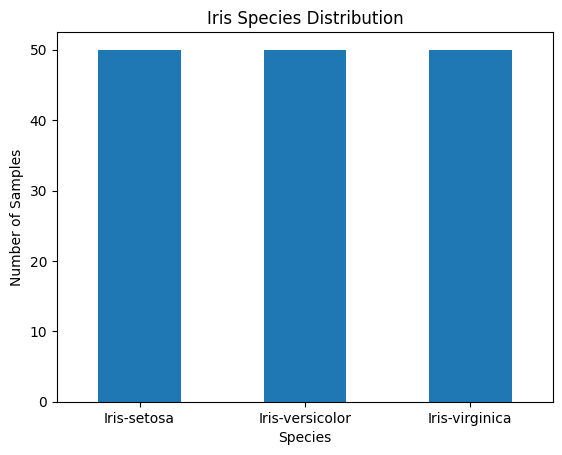

In [35]:


import matplotlib.pyplot as plt

df['Species'].value_counts().plot(kind='bar')

plt.title("Iris Species Distribution")
plt.xlabel("Species")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

plt.show()

Separate Features & Target

In [36]:
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


Pair Plot of Iris Dataset

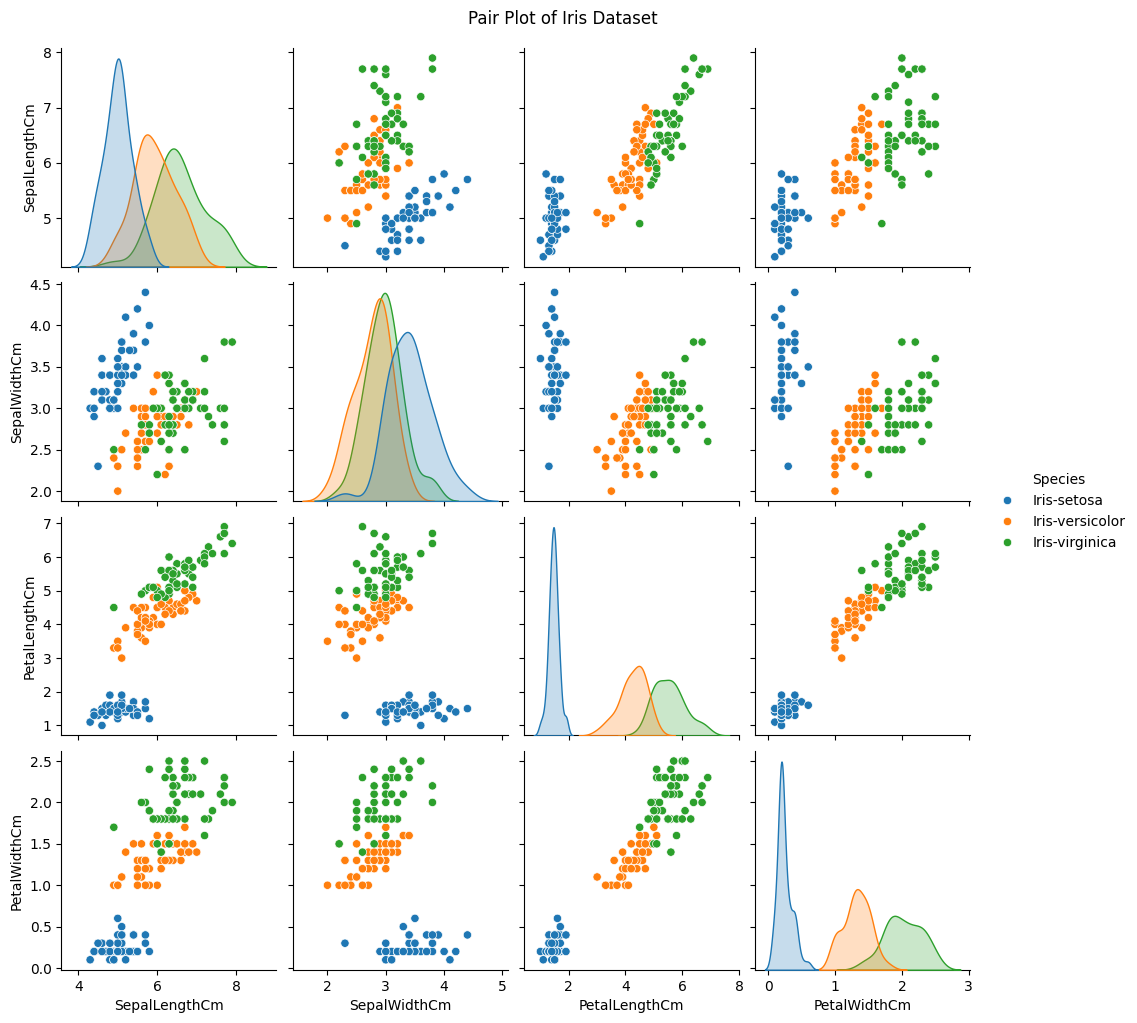

In [37]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']],
    hue="Species"
)

plt.suptitle("Pair Plot of Iris Dataset", y=1.02)
plt.show()

Feature Correlation Heatmap

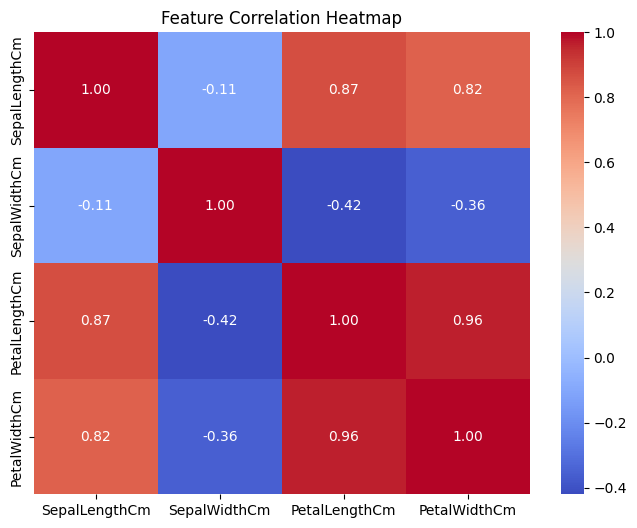

In [38]:


import seaborn as sns
import matplotlib.pyplot as plt

correlation = X.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

Split Data into Training & Testing

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


Train the ML Model

In [40]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_model = KNeighborsClassifier()

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy * 100, "%")

KNN Accuracy: 100.0 %


In [42]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=200)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy * 100, "%")

Logistic Regression Accuracy: 96.66666666666667 %


In [43]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy * 100, "%")

Decision Tree Accuracy: 93.33333333333333 %


In [44]:
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy * 100, "%")

SVM Accuracy: 96.66666666666667 %


In [45]:
from sklearn.metrics import accuracy_score

models = [
    "Random Forest",
    "KNN",
    "Logistic Regression",
    "Decision Tree",
    "SVM"
]

# Calculate Random Forest accuracy
rf_pred = model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred) * 100

accuracies = [
    rf_accuracy,
    knn_accuracy * 100,
    lr_accuracy * 100,
    dt_accuracy * 100,
    svm_accuracy * 100
]

for model_name, acc in zip(models, accuracies):
    print(f"{model_name}: {acc:.2f}%")

Random Forest: 90.00%
KNN: 100.00%
Logistic Regression: 96.67%
Decision Tree: 93.33%
SVM: 96.67%


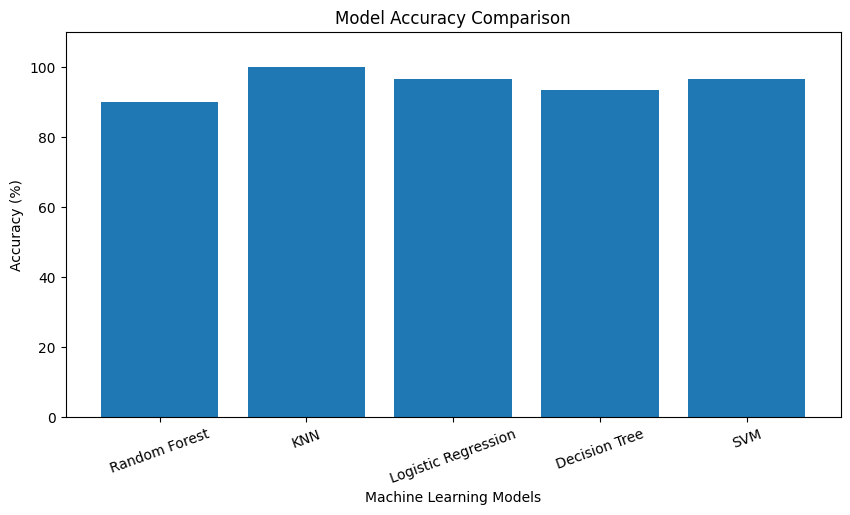

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(models, accuracies)

plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")

plt.ylim(0, 110)
plt.xticks(rotation=20)

plt.show()

In [47]:
best_index = accuracies.index(max(accuracies))

best_model_name = models[best_index]
best_accuracy = accuracies[best_index]

print("Best Model:", best_model_name)
print("Best Accuracy:", f"{best_accuracy:.2f}%")

Best Model: KNN
Best Accuracy: 100.00%


Final Model: KNN
Accuracy: 100.00%

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



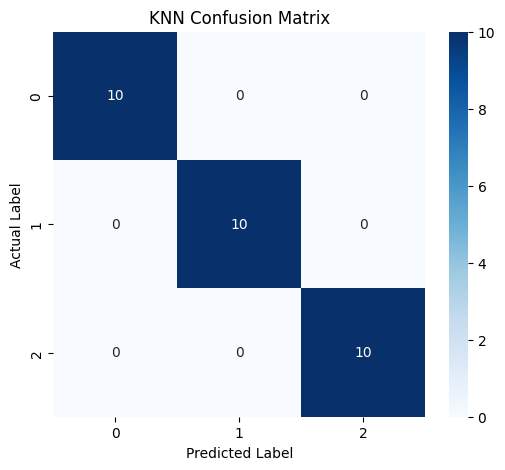

In [48]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("Final Model: KNN")
print("Accuracy:", f"{knn_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, knn_pred))

cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("KNN Confusion Matrix")

plt.show()

Actual vs Predicted

In [49]:


comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': knn_pred
})

comparison.head(10)

,Actual,Predicted
0,Iris-setosa,Iris-setosa
1,Iris-virginica,Iris-virginica
2,Iris-versicolor,Iris-versicolor
3,Iris-versicolor,Iris-versicolor
4,Iris-setosa,Iris-setosa
5,Iris-versicolor,Iris-versicolor
6,Iris-setosa,Iris-setosa
7,Iris-setosa,Iris-setosa
8,Iris-virginica,Iris-virginica
9,Iris-versicolor,Iris-versicolor


Final Model Performance

In [50]:


correct = sum(y_test == knn_pred)
incorrect = len(y_test) - correct

print("Final Model: KNN")
print("Correct Predictions:", correct)
print("Incorrect Predictions:", incorrect)
print("Accuracy:", f"{knn_accuracy * 100:.2f}%")

Final Model: KNN
Correct Predictions: 30
Incorrect Predictions: 0
Accuracy: 100.00%


Project Summary
Iris Flower Classification

Objective:
The objective of this project is to classify Iris flowers into three species — Iris-setosa, Iris-versicolor, and Iris-virginica — using machine learning classification algorithms.

Dataset:
The Iris dataset contains 150 samples with 4 features: Sepal Length, Sepal Width, Petal Length, and Petal Width.

Algorithms Used:
K-Nearest Neighbors (KNN), Logistic Regression, Decision Tree, Support Vector Machine (SVM), and Random Forest.

Model Comparison:
The models were trained and evaluated using the same train-test split. KNN achieved 100%, Logistic Regression 96.67%, SVM 96.67%, Decision Tree 93.33%, and Random Forest 90% accuracy.

Best Result:
The KNN model achieved 100% test accuracy, correctly classifying all 30 test samples.

Conclusion:
The project successfully demonstrates how machine learning algorithms can be used to classify Iris flower species based on their sepal and petal measurements.

In [53]:
# Save Final KNN Model

import joblib

joblib.dump(knn_model, "iris_knn_model.pkl")

print("KNN model saved successfully!")

KNN model saved successfully!
